# Environment Set-up

In [42]:
# Install dependencies (uncomment if running in Colab)
# %pip install -q pandas numpy matplotlib seaborn plotly scikit-learn xgboost catboost lightgbm

import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.ticker import PercentFormatter
from pandas.api.types import is_numeric_dtype

# Machine Learning
import xgboost as xgb
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, FunctionTransformer, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_auc_score
)

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")

pandas: 2.1.4
numpy: 1.26.4


In [43]:
# === DATA PATH CONFIGURATION ===
# Data is resolved in this order, so a fresh clone needs no manual setup:
#   1. Google Drive, when running in Colab
#   2. Olist_CSV in the project root, if it is already there
#   3. the olist_csv.zip bundled in the repo, extracted on first run
import os
import zipfile

COLAB_DATA_DIR = "/content/drive/MyDrive/NUS/IT5006/Group Project/IT5006_Project-Data/Olist_CSV"
# Support kernels started from either the project root or phase2.
PROJECT_ROOT = os.path.abspath(".." if os.path.basename(os.getcwd()) == "phase2" else ".")
LOCAL_DATA_DIR = os.path.join(PROJECT_ROOT, "Olist_CSV")
BUNDLED_ARCHIVE = os.path.join(PROJECT_ROOT, "streamlit_release", "data", "olist_csv.zip")

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = COLAB_DATA_DIR
except ModuleNotFoundError:
    DATA_DIR = LOCAL_DATA_DIR

if not os.path.isdir(DATA_DIR) and os.path.isfile(BUNDLED_ARCHIVE):
    print(f"Extracting {BUNDLED_ARCHIVE} -> {LOCAL_DATA_DIR}")
    with zipfile.ZipFile(BUNDLED_ARCHIVE) as archive:
        archive.extractall(LOCAL_DATA_DIR)
    DATA_DIR = LOCAL_DATA_DIR

# Verify data directory exists (isdir, not exists: a .zip path would pass exists)
if os.path.isdir(DATA_DIR):
    print(f"\u2705 Data directory found: {DATA_DIR}")
    print(f"   Files: {os.listdir(DATA_DIR)}")
else:
    print(f"\u274c Data directory not found: {DATA_DIR}")
    print("   Please update DATA_DIR to point to your Olist data folder")

✅ Data directory found: c:\Users\D00mG\OneDrive\Documents\NUS\github\Team8_IT5006_Ecommerce_Analytics_AY2627Sem1\Olist_CSV
   Files: ['olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv', 'olist_sellers_dataset.csv', 'product_category_name_translation.csv']


# Load data

In [44]:
# Load all Olist tables
def load_olist_data(data_dir):
    """Load all Olist CSV files into a dictionary of DataFrames."""

    tables = {
        'orders': 'olist_orders_dataset.csv',
        'order_items': 'olist_order_items_dataset.csv',
        'customers': 'olist_customers_dataset.csv',
        'products': 'olist_products_dataset.csv',
        'sellers': 'olist_sellers_dataset.csv',
        'payments': 'olist_order_payments_dataset.csv',
        'reviews': 'olist_order_reviews_dataset.csv',
        'geolocation': 'olist_geolocation_dataset.csv',
        'category_translation': 'product_category_name_translation.csv'
    }

    # Date columns to parse
    date_cols = {
        'orders': ['order_purchase_timestamp', 'order_approved_at',
                   'order_delivered_carrier_date', 'order_delivered_customer_date',
                   'order_estimated_delivery_date'],
        'order_items': ['shipping_limit_date'],
        'reviews': ['review_creation_date', 'review_answer_timestamp']
    }

    data = {}
    for name, filename in tables.items():
        filepath = os.path.join(data_dir, filename)
        parse_dates = date_cols.get(name, None)
        data[name] = pd.read_csv(filepath, parse_dates=parse_dates)
        print(f"Loaded {name}: {data[name].shape[0]:,} rows × {data[name].shape[1]} cols")

    return data

# Load data

olist = load_olist_data(DATA_DIR)

orders = olist['orders']
order_items = olist['order_items']
customers = olist['customers']
products = olist['products']
sellers = olist['sellers']
payments = olist['payments']
reviews = olist['reviews']
geolocation = olist['geolocation']
category_translation = olist['category_translation']

Loaded orders: 99,441 rows × 8 cols
Loaded order_items: 112,650 rows × 7 cols
Loaded customers: 99,441 rows × 5 cols
Loaded products: 32,951 rows × 9 cols
Loaded sellers: 3,095 rows × 4 cols
Loaded payments: 103,886 rows × 5 cols
Loaded reviews: 99,224 rows × 7 cols
Loaded geolocation: 1,000,163 rows × 5 cols
Loaded category_translation: 71 rows × 2 cols


In [45]:
# Translate product catgory names and clean up missing values
count_products_cat_1 = products['product_category_name'].nunique(dropna=False)
count_products_cat_2 = category_translation['product_category_name_english'].nunique(dropna=False)
print(f"products table have {count_products_cat_1} product categories")
print(f"category_translation table have {count_products_cat_2} product categories")

products = products.merge(category_translation, on='product_category_name', how='left')
products["product_category_name"] = (products["product_category_name_english"]
                                    .combine_first(products["product_category_name"])
                                    .fillna("Unknown")
                                    )
products.drop(columns=['product_category_name_english'], inplace=True)

products table have 74 product categories
category_translation table have 71 product categories


# Constants

In [46]:
RANDOM_STATE = 42
LOOKBACK = 30
PXD = 180

# Feature Engineeering
- Currently only have basic features obtained directly from the tables
- Some additional features ideas:
    - Holiday/busy period indicators
    - Distance between seller and customer (Need to aggregate due to 1 customer to many sellers r/s)
    - Same-state/interstate deliveries indicator

## Orders and Customers

In [47]:
# Delivered orders
dlv_orders = orders[orders['order_status']=='delivered']
dlv_orders['order_approved_dt'] = dlv_orders['order_approved_at'].dt.normalize()
dlv_orders['order_approved_day_of_week'] = (dlv_orders['order_approved_dt'].dt.dayofweek + 1).astype('Int64')
dlv_orders['order_approved_day_of_month'] = (dlv_orders['order_approved_dt'].dt.day).astype('Int64')
dlv_orders['order_approved_month'] = dlv_orders['order_approved_dt'].dt.month.astype('Int64')
dlv_orders['order_approved_week_of_year'] = dlv_orders['order_approved_dt'].dt.isocalendar().week.clip(upper=52).astype('Int64')
dlv_orders['partition_yyyymm'] = dlv_orders['order_approved_at'].dt.to_period('M').astype(str)
dlv_orders["durn_to_carrier_days"] = (dlv_orders["order_delivered_carrier_date"] - dlv_orders["order_approved_at"]).dt.total_seconds()/86400
dlv_orders["durn_to_customer_days"] = (dlv_orders["order_delivered_customer_date"] - dlv_orders["order_approved_at"]).dt.total_seconds()/86400


# Dependent variables
## Classification Binary indicator: 0 - On Time, 1 - Late
dlv_orders['dpt_var_late_delivery'] = (dlv_orders['order_delivered_customer_date'].dt.normalize() > dlv_orders['order_estimated_delivery_date']).astype(int) 
## Regression - To discuss
dlv_orders["dpt_var_est_vs_delivered_days"] = (dlv_orders['order_delivered_customer_date'].dt.normalize() - dlv_orders["order_estimated_delivery_date"]).dt.total_seconds()/86400


# Add customer features
dlv_orders = dlv_orders.merge(customers, on='customer_id', how='left')

dlv_orders.drop(columns=['order_status'], inplace=True)

print(dlv_orders.shape)
print(f"Unique order_id: {dlv_orders['order_id'].nunique()}")
display(dlv_orders[dlv_orders['dpt_var_late_delivery']==1].head(5))

(96478, 21)
Unique order_id: 96478


,order_id,customer_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_approved_dt,order_approved_day_of_week,order_approved_day_of_month,order_approved_month,order_approved_week_of_year,partition_yyyymm,durn_to_carrier_days,durn_to_customer_days,dpt_var_late_delivery,dpt_var_est_vs_delivered_days,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
19,203096f03d82e0dffbc41ebc2e2bcfb7,d2b091571da224a1b36412c18bc3bbfe,2017-09-18 14:31:30,2017-09-19 04:04:09,2017-10-06 17:50:03,2017-10-09 22:23:46,2017-09-28,2017-09-19,2,19,9,38,2017-09,17.57,20.76,1,11.00,d699688533772c15a061e8ce81cb56df,4001,sao paulo,SP
24,fbf9ac61453ac646ce8ad9783d7d0af6,3a874b4d4c4b6543206ff5d89287f0c3,2018-02-20 23:46:53,2018-02-22 02:30:46,2018-02-26 22:25:22,2018-03-21 22:03:54,2018-03-12,2018-02-22,4,22,2,8,2018-02,4.83,27.81,1,9.00,a25d5f94840d3c6a1a49f271ed83f4ec,21715,rio de janeiro,RJ
40,6ea2f835b4556291ffdc53fa0b3b95e8,c7340080e394356141681bd4c9b8fe31,2017-11-24 21:27:48,2017-11-25 00:21:09,2017-12-13 21:14:05,2017-12-28 18:59:23,2017-12-21,2017-11-25,6,25,11,47,2017-11,18.87,33.78,1,7.00,3e4fd73f1e86b135b9b121d6abbe9597,19400,presidente venceslau,SP
55,66e4624ae69e7dc89bd50222b59f581f,684fa6da5134b9e4dab731e00011712d,2018-03-09 14:50:15,2018-03-09 15:40:39,2018-03-15 00:31:19,2018-04-03 13:28:46,2018-04-02,2018-03-09,5,9,3,10,2018-03,5.37,24.91,1,1.00,ddf60e20e6e262e2136801ce5cd628b0,49030,aracaju,SE
56,a685d016c8a26f71a0bb67821070e398,911e4c37f5cafe1604fe6767034bf1ae,2017-03-13 18:14:36,2017-03-13 18:14:36,2017-03-22 14:03:09,2017-04-06 13:37:16,2017-03-30,2017-03-13,1,13,3,11,2017-03,8.83,23.81,1,7.00,51838d41add414a0b1b989b7d251d9ee,13068,campinas,SP


## Get inter-state/same-state tagging

In [48]:
all_order_items = order_items.merge(sellers[['seller_id', 'seller_state', 'seller_city']]
                                        , on='seller_id'
                                        , how='left'
                                        )
orders_routes = dlv_orders.merge(all_order_items,
                                    on='order_id',
                                    how='left'
                                    )
orders_routes.drop(columns=['product_id', 'shipping_limit_date'], inplace=True)
orders_routes = orders_routes.sort_values(['order_id', 'seller_id'])

orders_routes['item_is_interstate'] = orders_routes['customer_state'] != orders_routes['seller_state']

groupby_cols = ['order_id', 'customer_state']
orders_routes_states = orders_routes.groupby(groupby_cols).agg(
                                    seller_count=('seller_id', 'nunique'),
                                    seller_state_count=('seller_state', 'nunique'),
                                    interstate_item_count=('item_is_interstate', 'sum'),
                                    item_count=('order_item_id', 'count'),
                                    all_interstate=('item_is_interstate', 'all'),
                                    any_interstate=('item_is_interstate', 'any')
                                ).reset_index()
orders_routes_states['route_type'] = np.select([orders_routes_states['all_interstate'], ~orders_routes_states['any_interstate']],
                                                ['1. All interstate', '2. All same-state'],
                                               default='3. Mixed'
                                               )
print(f"Unique orders: {orders_routes_states['order_id'].nunique()}")
print(f"Shape: {orders_routes_states.shape}")
display(orders_routes_states.head())
orders_routes_states['route_type'].value_counts()

Unique orders: 96478
Shape: (96478, 9)


,order_id,customer_state,seller_count,seller_state_count,interstate_item_count,item_count,all_interstate,any_interstate,route_type
0,00010242fe8c5a6d1ba2dd792cb16214,RJ,1,1,1,1,True,True,1. All interstate
1,00018f77f2f0320c557190d7a144bdd3,SP,1,1,0,1,False,False,2. All same-state
2,000229ec398224ef6ca0657da4fc703e,MG,1,1,0,1,False,False,2. All same-state
3,00024acbcdf0a6daa1e931b038114c75,SP,1,1,0,1,False,False,2. All same-state
4,00042b26cf59d7ce69dfabb4e55b4fd9,SP,1,1,1,1,True,True,1. All interstate


route_type
1. All interstate    61651
2. All same-state    34580
3. Mixed               247
Name: count, dtype: int64

## Seller-customer distance

In [49]:
geo_by_zip = (
    geolocation
    .groupby('geolocation_zip_code_prefix', as_index=False)
    .agg(
        latitude=('geolocation_lat', 'median'),
        longitude=('geolocation_lng', 'median')
    )
)

customer_coordinates = (
    customers[['customer_id', 'customer_zip_code_prefix']]
    .merge(
        geo_by_zip.rename(columns={
            'geolocation_zip_code_prefix': 'customer_zip_code_prefix',
            'latitude': 'customer_latitude',
            'longitude': 'customer_longitude'
        }),
        on='customer_zip_code_prefix',
        how='left'
    )
)

seller_coordinates = (
    sellers[['seller_id', 'seller_zip_code_prefix']]
    .merge(
        geo_by_zip.rename(columns={
            'geolocation_zip_code_prefix': 'seller_zip_code_prefix',
            'latitude': 'seller_latitude',
            'longitude': 'seller_longitude'
        }),
        on='seller_zip_code_prefix',
        how='left'
    )
)

# One row per order-seller
distance_order_seller = (
    order_items[['order_id', 'seller_id']]
    .drop_duplicates()
    .merge(seller_coordinates, on='seller_id', how='left')
    .merge(
        orders[['order_id', 'customer_id']],
        on='order_id',
        how='left'
    )
    .merge(customer_coordinates, on='customer_id', how='left')
)

def haversine_km(lat1, lon1, lat2, lon2):
    """Vectorised great-circle distance in kilometres."""
    earth_radius_km = 6371.0088
    lat1_rad, lon1_rad = np.radians(lat1), np.radians(lon1)
    lat2_rad, lon2_rad = np.radians(lat2), np.radians(lon2)
    delta_lat = lat2_rad - lat1_rad
    delta_lon = lon2_rad - lon1_rad
    a = (
        np.sin(delta_lat / 2) ** 2
        + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(delta_lon / 2) ** 2
    )
    return 2 * earth_radius_km * np.arcsin(np.sqrt(a))

distance_order_seller['distance_km'] = haversine_km(
    distance_order_seller['seller_latitude'],
    distance_order_seller['seller_longitude'],
    distance_order_seller['customer_latitude'],
    distance_order_seller['customer_longitude']
)

distance_by_order = (
    distance_order_seller
    .groupby('order_id', as_index=False)
    .agg(
        seller_dist_km_max=('distance_km', 'max'),
        seller_dist_km_min=('distance_km', 'min'),
        seller_dist_km_median=('distance_km', 'median'),
        seller_dist_km_mean=('distance_km', 'mean'),
        seller_dist_km_count=('seller_id', 'nunique')
    )
)

distance_delivery = dlv_orders[['order_id']].merge(distance_by_order, on='order_id', how='left')

coordinate_coverage = distance_delivery['seller_dist_km_max'].notna().mean()
print(f"Delivered orders with usable distance: {coordinate_coverage:.1%}")
print(f"Unique orders: {distance_delivery['order_id'].nunique()}")
print(f"Shape: {distance_delivery.shape}")

display(distance_delivery[distance_delivery['seller_dist_km_count']>2].head())
display(distance_delivery['seller_dist_km_count'].value_counts(dropna=False))

Delivered orders with usable distance: 99.5%
Unique orders: 96478
Shape: (96478, 6)


,order_id,seller_dist_km_max,seller_dist_km_min,seller_dist_km_median,seller_dist_km_mean,seller_dist_km_count
585,a98012aa8c697f2bcff9f8c2183e0f2b,498.90,387.18,482.65,456.24,3
3474,780dfcd5aaf2662f3f6ce2201164394b,852.93,134.09,513.68,500.23,3
3737,bb44d0c37f5fcc456bbaefd9aef6adb8,525.84,202.23,363.87,363.98,3
3842,179e23361d372901e40a92f8c29bd61d,834.03,808.78,828.65,823.82,3
5086,d839ea07a528e914f89702508023da37,451.78,334.73,337.56,374.69,3


seller_dist_km_count
1    95203
2     1216
3       54
4        3
5        2
Name: count, dtype: int64

## Aggregate order items

In [50]:
all_order_items = order_items.copy()
all_order_items = all_order_items.merge(products[['product_id', 'product_category_name', 'product_photos_qty', 'product_weight_g']]
                                    , on='product_id'
                                    , how='left'
                                    )
all_order_items = all_order_items.merge(sellers, on='seller_id', how='left')
all_order_items['item_revenue'] = all_order_items['price'] + all_order_items['freight_value']
all_order_items = all_order_items.sort_values(['order_id', 'order_item_id'])
print(all_order_items.shape)
print(f"Unique order_id: {all_order_items['order_id'].nunique()}")

(112650, 14)
Unique order_id: 98666


In [51]:
order_items_agg = all_order_items.groupby('order_id').agg(
    order_item_count=('product_id', 'count'),
    order_seller_count=('seller_id', 'nunique'),
    order_pdt_price_sum=('price', 'sum'),
    order_frieght_value_sum=('freight_value', 'sum'),
    order_revenue_sum=('item_revenue', 'sum'),
    order_product_weight_g_sum=('product_weight_g', 'sum'),
    order_product_category_count=('product_category_name', 'nunique'),
    seller_zip_code_prefix_count=('seller_zip_code_prefix', 'nunique'),
    seller_city_count=('seller_city', 'nunique'),
    seller_state_count=('seller_state', 'nunique'),

    product_category_name=('product_category_name', set),
    seller_zip_code_prefix=('seller_zip_code_prefix', set),
    seller_city=('seller_city', set),
    seller_state=('seller_state', set),
).reset_index()

print(f"Shape: {order_items_agg.shape}")
print(f"Unique order_id: {order_items_agg['order_id'].nunique()}")
cond = (order_items_agg['order_item_count'] > 2) | (order_items_agg['order_seller_count'] > 1)
display(order_items_agg[cond].head())

# Sample order with >1 item
# display(all_order_items[all_order_items['order_id'] == 'fffb9224b6fc7c43ebb0904318b10b5f']) 

Shape: (98666, 15)
Unique order_id: 98666


,order_id,order_item_count,order_seller_count,order_pdt_price_sum,order_frieght_value_sum,order_revenue_sum,order_product_weight_g_sum,order_product_category_count,seller_zip_code_prefix_count,seller_city_count,seller_state_count,product_category_name,seller_zip_code_prefix,seller_city,seller_state
31,00143d0f86d6fbd9f9b38ab440ac16f5,3,1,63.99,45.30,109.29,540.00,1,1,1,1,{sports_leisure},{18055},{sorocaba},{SP}
39,001ab0a7578dd66cd4b0a71f5b6e1e41,3,1,74.67,52.89,127.56,450.00,1,1,1,1,{electronics},{72015},{brasilia},{DF}
73,002f98c0f7efd42638ed6100ca699b42,2,2,53.89,39.73,93.62,650.00,2,2,2,2,"{consoles_games, toys}","{38440, 2310}","{sao paulo, araguari}","{SP, MG}"
124,00526a9d4ebde463baee25f386963ddc,4,1,135.56,33.60,169.16,1552.00,1,1,1,1,{food},{3279},{sao paulo},{SP}
134,005d9a5423d47281ac463a968b3936fb,3,1,99.97,45.28,145.25,350.00,2,1,1,1,"{baby, toys}",{90010},{porto alegre},{RS}


## Aggregate payments

In [52]:
payment_type_agg = payments.pivot_table(
    index='order_id',
    columns='payment_type',
    values='payment_value',
    aggfunc=['sum', 'size'],
    fill_value=0,
)

payment_type_agg.columns = [
    f"payment_type_{'count' if agg == 'size' else 'value'}_{ptype}"
    for agg, ptype in payment_type_agg.columns
]

# Note: Current code does not guard against new payment types in future
payments_agg = (
    payments.groupby('order_id')
    .agg(payment_value_sum=('payment_value', 'sum'))
    .join(payment_type_agg)
    .reset_index()
)
print(f"Shape: {payments_agg.shape}")
print(f"Unique order_id: {payments_agg['order_id'].nunique()}")

# Check samples
samples = ['0016dfedd97fc2950e388d2971d718c7', '009ac365164f8e06f59d18a08045f6c4', 'fee9afa24ed743a26803c4d03e8ba5e1']
display(payments_agg[payments_agg['order_id'].isin(samples)])
display(payments[payments['order_id'].isin(samples)].sort_values(['order_id', 'payment_sequential']))

Shape: (99440, 12)
Unique order_id: 99440


,order_id,payment_value_sum,payment_type_value_boleto,payment_type_value_credit_card,payment_type_value_debit_card,payment_type_value_not_defined,payment_type_value_voucher,payment_type_count_boleto,payment_type_count_credit_card,payment_type_count_debit_card,payment_type_count_not_defined,payment_type_count_voucher
36,0016dfedd97fc2950e388d2971d718c7,70.55,0.00,52.63,0.00,0.00,17.92,0,1,0,0,1
215,009ac365164f8e06f59d18a08045f6c4,32.00,0.00,0.88,0.00,0.00,31.12,0,1,0,0,5
99040,fee9afa24ed743a26803c4d03e8ba5e1,61.78,0.00,61.78,0.00,0.00,0.00,0,2,0,0,0


,order_id,payment_sequential,payment_type,payment_installments,payment_value
89575,0016dfedd97fc2950e388d2971d718c7,1,credit_card,5,52.63
80856,0016dfedd97fc2950e388d2971d718c7,2,voucher,1,17.92
16053,009ac365164f8e06f59d18a08045f6c4,1,credit_card,1,0.88
16459,009ac365164f8e06f59d18a08045f6c4,2,voucher,1,4.50
73837,009ac365164f8e06f59d18a08045f6c4,3,voucher,1,8.25
32058,009ac365164f8e06f59d18a08045f6c4,4,voucher,1,5.45
285,009ac365164f8e06f59d18a08045f6c4,5,voucher,1,8.75
15298,009ac365164f8e06f59d18a08045f6c4,6,voucher,1,4.17
41032,fee9afa24ed743a26803c4d03e8ba5e1,1,credit_card,3,37.89
87715,fee9afa24ed743a26803c4d03e8ba5e1,2,credit_card,2,23.89


## Make dataset
- Final dataframe containing all features, the partition month and the dependent variables
- Features to be expanded with further engineering

In [53]:
final_df = dlv_orders.merge(orders_routes_states[['order_id', 'route_type']], on='order_id', how='left'
                    ).merge(distance_delivery, on='order_id', how='left'
                    ).merge(order_items_agg, on='order_id', how='left'
                    ).merge(payments_agg, on='order_id', how='left'
                    )

print(f"Shape: {final_df.shape}")
print(f"Unique order_id: {final_df['order_id'].nunique()}")

print("\nAfter filtering for orders >= 2017-01...")
final_df = final_df[final_df['partition_yyyymm'] >= '2017-01']
print(f"Shape: {final_df.shape}")
print(f"Unique order_id: {final_df['order_id'].nunique()}")

print("\nAfter dropping rows with null values...")
final_df = final_df.dropna()
print(f"Shape: {final_df.shape}")
print(f"Unique order_id: {final_df['order_id'].nunique()}")

print(final_df.shape)

display(final_df.head())

Shape: (96478, 52)
Unique order_id: 96478

After filtering for orders >= 2017-01...
Shape: (96211, 52)
Unique order_id: 96211

After dropping rows with null values...
Shape: (95712, 52)
Unique order_id: 95712
(95712, 52)


,order_id,customer_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_approved_dt,order_approved_day_of_week,order_approved_day_of_month,order_approved_month,order_approved_week_of_year,partition_yyyymm,durn_to_carrier_days,durn_to_customer_days,dpt_var_late_delivery,dpt_var_est_vs_delivered_days,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,route_type,seller_dist_km_max,seller_dist_km_min,seller_dist_km_median,...,order_item_count,order_seller_count,order_pdt_price_sum,order_frieght_value_sum,order_revenue_sum,order_product_weight_g_sum,order_product_category_count,seller_zip_code_prefix_count,seller_city_count,seller_state_count,product_category_name,seller_zip_code_prefix,seller_city,seller_state,payment_value_sum,payment_type_value_boleto,payment_type_value_credit_card,payment_type_value_debit_card,payment_type_value_not_defined,payment_type_value_voucher,payment_type_count_boleto,payment_type_count_credit_card,payment_type_count_debit_card,payment_type_count_not_defined,payment_type_count_voucher
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10-02,1,2,10,40,2017-10,2.37,8.43,0,-8.00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2. All same-state,18.68,18.68,18.68,...,1,1,29.99,8.72,38.71,500.00,1,1,1,1,{housewares},{9350},{maua},{SP},38.71,0.00,18.12,0.00,0.00,20.59,0.00,1.00,0.00,0.00,2.00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07-26,4,26,7,30,2018-07,0.46,12.50,0,-6.00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1. All interstate,861.04,861.04,861.04,...,1,1,118.70,22.76,141.46,400.00,1,1,1,1,{perfumery},{31570},{belo horizonte},{SP},141.46,141.46,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08-08,3,8,8,32,2018-08,0.20,9.38,0,-18.00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1. All interstate,514.55,514.55,514.55,...,1,1,159.90,19.22,179.12,420.00,1,1,1,1,{auto},{14840},{guariba},{SP},179.12,0.00,179.12,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11-18,6,18,11,46,2017-11,3.75,13.20,0,-13.00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1. All interstate,1821.81,1821.81,1821.81,...,1,1,45.00,27.20,72.20,450.00,1,1,1,1,{pet_shop},{31842},{belo horizonte},{MG},72.20,0.00,72.20,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02-13,2,13,2,7,2018-02,0.89,2.83,0,-10.00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,2. All same-state,29.59,29.59,29.59,...,1,1,19.90,8.72,28.62,250.00,1,1,1,1,{stationery},{8752},{mogi das cruzes},{SP},28.62,0.00,28.62,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00


## Sanity checks

### Monthly aggregation
- Monthly delivered order counts is between 4k to 7k
- Late delivery rates tend to fluctuate
    - The train-test split by sequential months may not be feasible
    - To perform train-test split by proportion, stratified by dependent variable

In [54]:
groupby_cols = ['partition_yyyymm']
grouped = final_df.groupby(groupby_cols).agg(
    orders = ('order_id', 'nunique'),
    order_revenue_sum = ('order_revenue_sum', 'sum'),
    late_rate = ('dpt_var_late_delivery', 'mean')
).reset_index().sort_values('partition_yyyymm', ascending=False)
grouped['late_rate'] = (grouped['late_rate']*100).round(2)
display(grouped)

,partition_yyyymm,orders,order_revenue_sum,late_rate
19,2018-08,6475,1009922.47,6.25
18,2018-07,6026,1002860.74,3.15
17,2018-06,6066,1011120.22,1.15
16,2018-05,6906,1151064.29,6.53
15,2018-04,6605,1104713.87,4.62
14,2018-03,7048,1127755.20,19.18
13,2018-02,6498,953478.89,13.60
12,2018-01,6958,1064397.49,5.65
11,2017-12,5645,864134.27,7.85
10,2017-11,7113,1129155.98,12.26


### Daily aggregation

,order_approved_dt,orders,order_revenue_sum,late_rate
596,2018-08-29,15,2298.71,0.00
595,2018-08-28,56,5738.28,0.00
594,2018-08-27,63,6238.46,0.00
593,2018-08-26,69,11392.46,0.00
592,2018-08-25,81,10514.98,0.00
...,...,...,...,...
4,2017-01-09,4,863.31,25.00
3,2017-01-08,2,225.96,0.00
2,2017-01-07,33,2019.30,3.03
1,2017-01-06,3,966.83,0.00


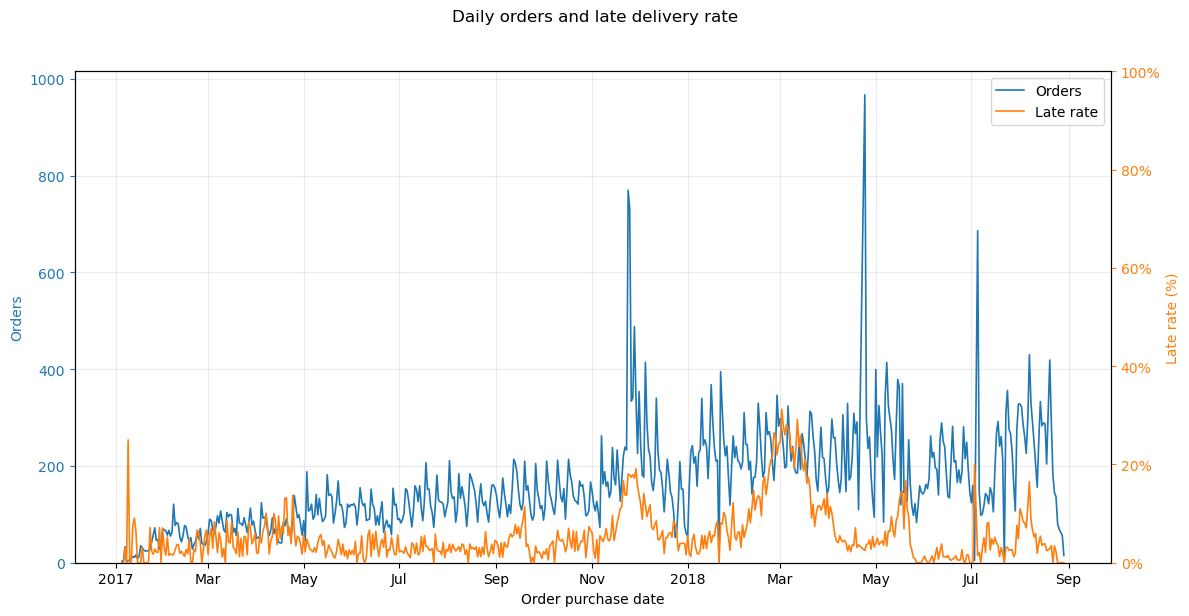

In [55]:
groupby_cols = ['order_approved_dt']
grouped = final_df.groupby(groupby_cols).agg(
    orders = ('order_id', 'nunique'),
    order_revenue_sum = ('order_revenue_sum', 'sum'),
    late_rate = ('dpt_var_late_delivery', 'mean')
).reset_index().sort_values('order_approved_dt', ascending=False)
grouped['late_rate'] = (grouped['late_rate']*100).round(2)
display(grouped)

# Share the purchase-date x-axis, with independent left/right y-axes.
plot_df = grouped.sort_values('order_approved_dt')
fig, ax_orders = plt.subplots(figsize=(12, 6))
ax_late = ax_orders.twinx()

orders_line, = ax_orders.plot(plot_df['order_approved_dt'], plot_df['orders'],
                              color='tab:blue', label='Orders', linewidth=1.2)
late_line, = ax_late.plot(plot_df['order_approved_dt'], plot_df['late_rate'],
                          color='tab:orange', label='Late rate', linewidth=1.2)

ax_orders.set_xlabel('Order purchase date')
ax_orders.set_ylabel('Orders', color='tab:blue')
ax_orders.tick_params(axis='y', colors='tab:blue')
ax_orders.set_ylim(bottom=0)
ax_late.set_ylabel('Late rate (%)', color='tab:orange')
ax_late.tick_params(axis='y', colors='tab:orange')
ax_late.set_ylim(0, 100)
ax_late.yaxis.set_major_formatter(PercentFormatter(xmax=100))
date_locator = mdates.AutoDateLocator()
ax_orders.xaxis.set_major_locator(date_locator)
ax_orders.xaxis.set_major_formatter(mdates.ConciseDateFormatter(date_locator))
ax_orders.grid(alpha=0.25)
ax_orders.legend(handles=[orders_line, late_line], loc='best')
fig.suptitle('Daily orders and late delivery rate', y=1.02)
fig.tight_layout()
plt.show()

# Helper functions

In [56]:
def get_train_test_period(inference_date: str, lookback: int = 30, pXd: int = 180):
    """Return YYYY-MM-DD strings; start is pXd days before end."""
    if isinstance(pXd, bool) or not isinstance(pXd, int) or pXd < 0:
        raise ValueError('pXd must be a non-negative integer')

    inference_date = pd.Timestamp(inference_date).normalize()
    if pd.isna(inference_date):
        raise ValueError('inference_date must be a valid date')

    train_test_end_date = inference_date - pd.Timedelta(days=lookback)
    train_test_start_date = train_test_end_date - pd.Timedelta(days=pXd-1)
    return train_test_start_date.strftime('%Y-%m-%d'), train_test_end_date.strftime('%Y-%m-%d')

# Model training
- To operationalise this, I am thinking we need to run predictions on a daily basis, for example:
    - The prediction job is set to run at 0030 daily
    - At 2018-08-01 0030H, the orders approved on 2018-07-31 would have all came in. We want to predict whether the orders approved on 2018-07-31 will be late.
    - To do so, we look at the last delivered orders from 30 days ago (end_date) to past X days ago (start_date)
        - Run date: 2018-08-01
        - Inference date: 2018-07-31 (we are predicting for orders approved on this date)
        - Train-test period: 2018-01-03 to 2018-07-01 based on lookback period of 30 days and pXd of 180 days
    - The lookback period serve as a buffer to identify whether orders will be late - **To verify suitability of 30 days**
    - pXd simply serve as the duration of train-test data (how much train & test data we want to use) - **To decide how much training data we want to use**

In [57]:
inference_date = '2018-07-31'
train_test_start_date, train_test_end_date = get_train_test_period(inference_date, lookback=LOOKBACK, pXd=PXD)
print(f"Train-test period for the inference date of {inference_date}:")
print(f"    {train_test_start_date} to {train_test_end_date} ({PXD} days)")

Train-test period for the inference date of 2018-07-31:
    2018-01-03 to 2018-07-01 (180 days)


In [58]:
train_test_df = final_df[
    final_df['order_approved_dt'].between(
        train_test_start_date,
        train_test_end_date,
        inclusive='both'
    )
].copy()
train_test_df['order_approved_dt'].value_counts().sort_index()

order_approved_dt
2018-01-03    231
2018-01-04    242
2018-01-05    206
2018-01-06    219
2018-01-07    158
             ... 
2018-06-27    215
2018-06-28    249
2018-06-29    192
2018-06-30    145
2018-07-01    124
Name: count, Length: 177, dtype: int64

In [59]:
# To save in a separate .py file once finalised
NUM_COLS = ['order_approved_day_of_week',
            'order_approved_day_of_month',
            'order_approved_month',
            'order_approved_week_of_year',
            'order_item_count',
            'order_seller_count',
            'order_pdt_price_sum',
            'order_frieght_value_sum',
            'order_revenue_sum',
            'order_product_weight_g_sum',
            'order_product_category_count',
            'seller_dist_km_max',
            'seller_dist_km_min',
            'seller_dist_km_median',
            'seller_dist_km_mean',
            'seller_zip_code_prefix_count',
            'seller_city_count',
            'seller_state_count',
            'payment_value_sum',
            'payment_type_value_boleto',
            'payment_type_value_credit_card',
            'payment_type_value_debit_card',
            'payment_type_value_not_defined',
            'payment_type_value_voucher',
            'payment_type_count_boleto',
            'payment_type_count_credit_card',
            'payment_type_count_debit_card',
            'payment_type_count_not_defined',
            'payment_type_count_voucher',
            ]

CAT_COLS = ['customer_state',
            'route_type'
            ]
FEATURE_COLS = NUM_COLS + CAT_COLS
LABEL_COL = 'dpt_var_late_delivery'

In [60]:
X = train_test_df[FEATURE_COLS]
y = train_test_df[LABEL_COL]
test_size = 30/PXD
print(f"Test size: {test_size*100:.2f}%")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=42, stratify=y
)

print(f"\nData split complete:")
print(f"   Training: {len(X_train):,} samples ({y_train.mean()*100:.2f}% late)")
print(f"   Test:     {len(X_test):,} samples ({y_test.mean()*100:.2f}% late)")

Test size: 16.67%

Data split complete:
   Training: 33,325 samples (8.62% late)
   Test:     6,666 samples (8.63% late)


# Preprocessor

In [61]:
# Fit category mappings on training data inside each model pipeline.
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', 'passthrough', NUM_COLS),
        ('categorical', OneHotEncoder(handle_unknown='ignore'), CAT_COLS)
    ],
    sparse_threshold=0  # Keep a dense matrix for both tree models
)

In [62]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(scale_pos_weight)

10.595337508698679


# Model Training

## Logistic Regression

In [63]:
# Baseline with class balancing; preprocessing is fitted on training data only.
lr_preprocessor = ColumnTransformer([
    ('numeric', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]), NUM_COLS),
    ('categorical', OneHotEncoder(handle_unknown='ignore'), CAT_COLS),
])
lr_pipeline = Pipeline([
    ('preprocessor', lr_preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42,
    )),
])
lr_pipeline.fit(X_train, y_train)
print('Logistic Regression Pipeline trained!')

Logistic Regression Pipeline trained!


## XGBoost

In [64]:
xgb_classifier = xgb.XGBClassifier(
    n_estimators=100,           # Number of boosting rounds (trees)
    max_depth=6,                # Maximum tree depth (controls complexity)
    learning_rate=0.1,          # Step size shrinkage (prevents overfitting)
    scale_pos_weight=scale_pos_weight,  # Handle class imbalance
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Create Pipeline: preprocessor -> model
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb_classifier)
])

# Fit the entire pipeline (preprocessor + model) on training data
xgb_pipeline.fit(X_train, y_train)
print("   XGBoost Pipeline trained!")
print("   Pipeline steps: preprocessor -> classifier")

   XGBoost Pipeline trained!
   Pipeline steps: preprocessor -> classifier


## Random Forest

In [65]:
rf_classifier = RandomForestClassifier(
    n_estimators=100,           # Number of trees in the forest
    max_depth=10,               # Maximum tree depth
    class_weight='balanced',    # Auto-adjust weights inversely to class freq
    random_state=42,
    n_jobs=-1                   # Use all CPU cores for parallel training
)

# Create Pipeline with a fresh preprocessor
# (Each pipeline needs its own preprocessor to avoid conflicts)
rf_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier', rf_classifier)
])

# Fit the entire pipeline
rf_pipeline.fit(X_train, y_train)
print("   Random Forest Pipeline trained!")
print("   Pipeline steps: preprocessor -> classifier")

   Random Forest Pipeline trained!
   Pipeline steps: preprocessor -> classifier


## CatBoost

In [70]:
# Preserve column names for CatBoost's native categorical processing.
def prepare_catboost_features(X):
    prepared = X.copy()
    prepared[NUM_COLS] = prepared[NUM_COLS].astype(float)
    for column in CAT_COLS:
        prepared[column] = prepared[column].astype('string').fillna('Missing').astype(str)
    return prepared

cat_pipeline = Pipeline([
    ('preprocessor', FunctionTransformer(prepare_catboost_features, validate=False)),
    ('classifier', CatBoostClassifier(
        cat_features=CAT_COLS,
        iterations=100,
        scale_pos_weight=scale_pos_weight,
        random_seed=42,
        verbose=False,
        allow_writing_files=False,
    )),
])
cat_pipeline.fit(X_train, y_train)
print('CatBoost Pipeline trained!')

CatBoost Pipeline trained!


## LightGBM

In [68]:
lgb_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier', LGBMClassifier(
        scale_pos_weight=scale_pos_weight, 
        random_state=42, 
        verbosity=-1,
        n_jobs=-1,
    )),
])
lgb_pipeline.fit(X_train, y_train)
print('LightGBM Pipeline trained!')

LightGBM Pipeline trained!


# Feature importances

In [69]:
# Use encoded feature names in the same order as the model inputs.
xgb_feature_names = xgb_pipeline.named_steps['preprocessor'].get_feature_names_out()
xgb_booster = xgb_pipeline.named_steps['classifier'].get_booster()
xgb_gain = xgb_booster.get_score(importance_type='gain')
# Array inputs use f0, f1, ...; features unused in splits have zero gain.
xgb_feature_keys = xgb_booster.feature_names or [
    f'f{i}' for i in range(len(xgb_feature_names))
]
xgb_top20 = (
    pd.DataFrame({
        'feature': xgb_feature_names,
        'gain': [xgb_gain.get(key, 0.0) for key in xgb_feature_keys]
    })
    .sort_values('gain', ascending=False)
    .head(20).reset_index(drop=True)
)

rf_top20 = (
    pd.DataFrame({
        'feature': rf_pipeline.named_steps['preprocessor'].get_feature_names_out(),
        'impurity_importance': rf_pipeline.named_steps['classifier'].feature_importances_
    })
    .sort_values('impurity_importance', ascending=False)
    .head(20).reset_index(drop=True)
)

print('XGBoost: top 20 features by average gain')
display(xgb_top20)
print('Random Forest: top 20 features by mean decrease in impurity')
display(rf_top20)

XGBoost: top 20 features by average gain


,feature,gain
0,categorical__route_type_1. All interstate,259.63
1,numeric__order_approved_week_of_year,156.77
2,categorical__customer_state_SP,144.68
3,numeric__order_approved_month,122.83
4,numeric__seller_dist_km_min,83.61
5,categorical__customer_state_RJ,62.84
6,categorical__customer_state_PR,54.17
7,numeric__order_seller_count,47.61
8,numeric__seller_dist_km_median,45.86
9,categorical__customer_state_MG,40.02


Random Forest: top 20 features by mean decrease in impurity


,feature,impurity_importance
0,numeric__order_approved_week_of_year,0.21
1,numeric__order_approved_month,0.15
2,numeric__seller_dist_km_min,0.07
3,numeric__seller_dist_km_mean,0.06
4,numeric__seller_dist_km_max,0.05
5,numeric__seller_dist_km_median,0.05
6,categorical__customer_state_SP,0.04
7,numeric__order_frieght_value_sum,0.04
8,categorical__route_type_1. All interstate,0.03
9,numeric__order_approved_day_of_month,0.03


# Evaluation

In [ ]:
print("="*60)
print("STEP 6: EVALUATE PIPELINES")
print("="*60)

def evaluate_pipeline(pipeline, X_test, y_test, name):
    """
    Evaluate a pipeline and return metrics.

    Note: X_test contains RAW features (not preprocessed).
    The pipeline handles preprocessing internally.
    """
    # Pipeline handles preprocessing + prediction in one call
    y_pred = pipeline.predict(X_test)              # Binary: 0 or 1
    y_prob = pipeline.predict_proba(X_test)[:, 1]  # Probability of late delivery

    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob)
    }

    return metrics, y_pred, y_prob

# Evaluate pipelines (note: X_test is RAW data, pipeline handles preprocessing)
xgb_metrics, xgb_pred, xgb_prob = evaluate_pipeline(xgb_pipeline, X_test, y_test, "XGBoost")
rf_metrics, rf_pred, rf_prob = evaluate_pipeline(rf_pipeline, X_test, y_test, "Random Forest")
lr_metrics, lr_pred, lr_prob = evaluate_pipeline(lr_pipeline, X_test, y_test, "Logistic Regression")
cat_metrics, cat_pred, cat_prob = evaluate_pipeline(cat_pipeline, X_test, y_test, "CatBoost")
lgb_metrics, lgb_pred, lgb_prob = evaluate_pipeline(lgb_pipeline, X_test, y_test, "LightGBM")

metrics_summary = pd.DataFrame({
    'XGBoost': xgb_metrics,
    'Random Forest': rf_metrics,
    'Logistic Regression': lr_metrics,
    'CatBoost': cat_metrics,
    'LightGBM': lgb_metrics,
}).T
display((metrics_summary * 100).style.format("{:.2f}"))

model_scores = {
    'XGBoost': xgb_prob,
    'Random Forest': rf_prob,
    'Logistic Regression': lr_prob,
    'CatBoost': cat_prob,
    'LightGBM': lgb_prob,
}

STEP 6: EVALUATE PIPELINES

XGBoost Pipeline Results:
   Accuracy:  0.7676
   Precision: 0.2261
   Recall:    0.6991
   F1 Score:  0.3417
   ROC AUC:   0.8118

Random Forest Pipeline Results:
   Accuracy:  0.7756
   Precision: 0.2264
   Recall:    0.6626
   F1 Score:  0.3375
   ROC AUC:   0.7970

Logistic Regression Pipeline Results:
   Accuracy:  0.6734
   Precision: 0.1574
   Recall:    0.6400
   F1 Score:  0.2527
   ROC AUC:   0.7180

CatBoost Pipeline Results:
   Accuracy:  0.7732
   Precision: 0.2216
   Recall:    0.6487
   F1 Score:  0.3304
   ROC AUC:   0.7859

LightGBM Pipeline Results:
   Accuracy:  0.7729
   Precision: 0.2294
   Recall:    0.6922
   F1 Score:  0.3446
   ROC AUC:   0.8103


,accuracy,f1_score,precision,recall,roc_auc
XGBoost,0.77,0.34,0.23,0.70,0.81
Random Forest,0.78,0.34,0.23,0.66,0.80
Logistic Regression,0.67,0.25,0.16,0.64,0.72
CatBoost,0.77,0.33,0.22,0.65,0.79
LightGBM,0.77,0.34,0.23,0.69,0.81


## Compute coverage
- Coverage is a metric used to identify the proportion of positive labels by decile
- This can help business stakeholders undestand if they were to target say top 3 deciles (Top 30% riskest orders), what proportion of actual late orders they are able to capture
    - Need to make sure that the test set size represents a monthly order size, so I adjusted train-test split size to account for this

In [ ]:
def get_coverage(prob):
    # Create prediction results DataFrame
    predictions_df = pd.DataFrame({
        'actual_late_delivery': y_test,
        'prob_late_delivery': prob,
    }, index=y_test.index)

    # Split predictions into 10 deciles based on predicted probabilities
    bins = pd.qcut(
        predictions_df['prob_late_delivery'],
        q=10,
        labels=False,
        duplicates='drop',
    )
    predictions_df['decile'] = (bins.max() - bins + 1).astype('Int64')

    # Compute coverage summary
    decile_summary = (
        predictions_df.groupby('decile')
        .agg(
            number_of_orders=('actual_late_delivery', 'size'),
            positive_labels=('actual_late_delivery', 'sum'),
        )
        .sort_index(ascending=True)
    )

    decile_summary['cumulative_orders'] = (
        decile_summary['number_of_orders'].cumsum()
    )
    decile_summary['cumulative_positive_labels'] = (
        decile_summary['positive_labels'].cumsum()
    )
    decile_summary['late_delivery_rate'] = (
        decile_summary['positive_labels']
        / decile_summary['number_of_orders']
    )
    decile_summary['cumulative_late_delivery_rate'] = (
        decile_summary['cumulative_positive_labels']
        / decile_summary['cumulative_orders']
    )

    total_positive_labels = decile_summary['positive_labels'].sum()

    decile_summary['coverage'] = (
        decile_summary['cumulative_positive_labels'] / total_positive_labels
        if total_positive_labels > 0
        else float('nan')
    )

    decile_summary = decile_summary.reset_index()
    return decile_summary

In [ ]:
coverage_tables = {}
for name, scores in model_scores.items():
    print(f'\n{name} coverage')
    coverage_tables[name] = get_coverage(scores)
    display(coverage_tables[name])

xgb_coverage = coverage_tables['XGBoost']
rf_coverage = coverage_tables['Random Forest']
lr_coverage = coverage_tables['Logistic Regression']
cat_coverage = coverage_tables['CatBoost']
lgb_coverage = coverage_tables['LightGBM']

# Probability Distribution

In [ ]:
# Use the same bins and axis scales to compare all five models.
fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True, sharey=True)
bins = np.linspace(0, 1, 101)
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:purple', 'tab:brown']

for ax, (name, scores), color in zip(axes.flat, model_scores.items(), colors):
    ax.hist(scores, bins=bins, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(0.5, color='red', linestyle=':', linewidth=2, label='Score = 0.5')
    ax.set_title(name)
    ax.set_xlabel('Predicted late-delivery score')
    ax.set_ylabel('Number of orders')
    ax.set_xlim(0, 1)
    ax.tick_params(labelbottom=True)
    ax.legend()

for ax in list(axes.flat)[len(model_scores):]:
    ax.set_visible(False)

fig.suptitle('Test-set probability distributions')
plt.tight_layout()
plt.show()

# Inference
- Using the trained models, peform inference on a live cohort of newly aprroved orders
- Orders eligibility:
    - These orders are not delivered yet, they are all eligible orders approved on the inference date
- Chronological backtesting:
    - Since this is a daily operation, we probably need to run inference for multiple dates and collate them as the results for 1 model run

# Archive

In [28]:
def get_train_test_months(input_month: str, n_train_months: int = 6):
    """Return consecutive months before the input month, oldest first."""
    if isinstance(n_train_months, bool) or not isinstance(n_train_months, int) or n_train_months < 1:
        raise ValueError('n_train_months must be a positive integer')

    return pd.period_range(
        end=pd.Period(input_month, freq='M') - 2,
        periods=n_train_months,
        freq='M',
    ).astype(str).tolist()

In [29]:
inference_month = '2018-07'
train_test_months = get_train_test_months(inference_month)
print(f"Train-test months for the inference month of {inference_month}: {train_test_months}")

Train-test months for the inference month of 2018-07: ['2017-12', '2018-01', '2018-02', '2018-03', '2018-04', '2018-05']


In [30]:
def get_train_test_months(input_month: str, n_train_months: int = 4):
    """Return training months (oldest first) and the preceding test month."""
    import re

    if not isinstance(input_month, str) or not re.fullmatch(r'[0-9]{4}-(0[1-9]|1[0-2])', input_month):
        raise ValueError('input_month must be a string in YYYY-MM format')
    if isinstance(n_train_months, bool) or not isinstance(n_train_months, int) or n_train_months < 1:
        raise ValueError('n_train_months must be a positive integer')

    test_period = pd.Period(input_month, freq='M') - 1
    train_months = [
        str(test_period - offset)
        for offset in range(n_train_months, 0, -1)
    ]
    test_month = str(test_period)
    return train_months, test_month

train_months, test_month = get_train_test_months('2018-07')
print(f"Train months: {train_months}")
print(f"Test months: {test_month}")

Train months: ['2018-02', '2018-03', '2018-04', '2018-05']
Test months: 2018-06
